<a href="https://colab.research.google.com/github/HasankaRajakaruna/APAN56-Datathon/blob/main/risk_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
predictions = pd.read_csv('/content/drive/MyDrive/datathon/predictions_final.csv')
test = pd.read_csv('/content/drive/MyDrive/datathon/sorted_test_data.csv')

In [ ]:
num_high_risk = sum(1 for value in predictions['prob'] if value > 0.8)
num_medium_risk = sum(1 for value in predictions['prob'] if value > 0.5)

print(num_high_risk)
print(num_medium_risk)

2910
2954


In [ ]:
sorted_indices = np.argsort(predictions['prob'])
sorted_churn_probabilities = predictions['prob'][sorted_indices]

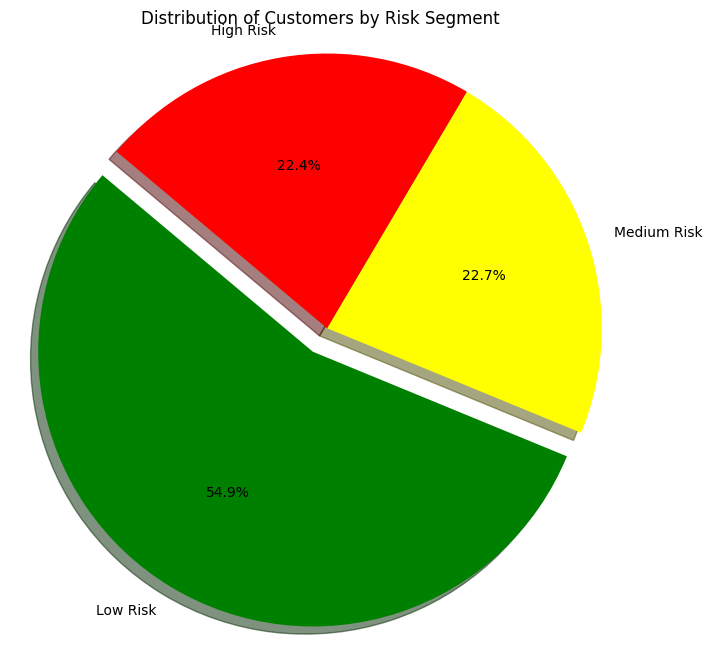

In [ ]:
high_risk_indices = sorted_indices[-num_high_risk:]
medium_risk_indices = sorted_indices[-num_high_risk - num_medium_risk:-num_high_risk]
low_risk_indices = sorted_indices[:-num_high_risk - num_medium_risk]

# Count the number of customers in each risk segment
num_low_risk = len(low_risk_indices)
num_medium_risk = len(medium_risk_indices)
num_high_risk = len(high_risk_indices)

# Create a pie chart
labels = ['Low Risk', 'Medium Risk', 'High Risk']
sizes = [num_low_risk, num_medium_risk, num_high_risk]
colors = ['green', 'yellow', 'red']
explode = (0.1, 0, 0)  # explode the 1st slice (Low Risk)

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.title('Distribution of Customers by Risk Segment')
plt.show()
